# Machine Learning Classification Workflow

## Diabetes Prediction on Clinical Dataset

This notebook uses the Pima Indians Diabetes dataset (`diabetes.csv`) to build and evaluate machine learning classification models that predict whether a patient is diabetic or non-diabetic.

The lab task requires an end-to-end workflow using Python, Pandas, and Scikit-Learn. Three distinct classification models are trained and compared using confusion matrices, precision, recall, F1-score, accuracy, and ROC curves. The final section also discusses the clinical trade-off between false positives and false negatives to select the best diagnostic predictor.

## Workflow

1. Import required libraries
2. Load and inspect the dataset
3. Clean missing and clinically invalid values
4. Perform exploratory data analysis
5. Split data into training and testing sets
6. Train three machine learning models
7. Compare performance using classification metrics
8. Plot confusion matrices and ROC curves
9. Analyze false positives vs false negatives
10. Select the best diagnostic model

In [14]:
# Import required libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [15]:
# Load the dataset
DATA_PATH = Path("diabetes.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
# Basic dataset information
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
df.describe().T

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical summary:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


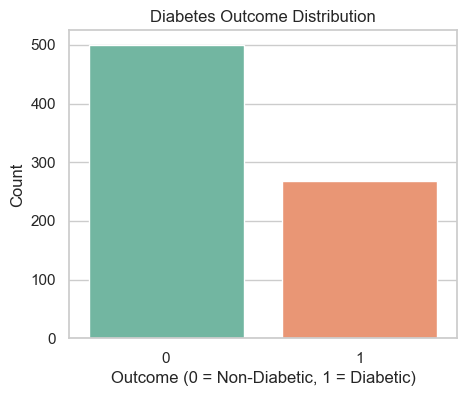

In [17]:
# Check missing values and class distribution
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTarget class distribution:")
print(df["Outcome"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Outcome", palette="Set2")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()

## Data Cleaning

In this clinical dataset, some variables cannot realistically be zero for a living patient. Values of `0` in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are treated as missing values and later imputed using the median value from the training data.

In [18]:
# Replace clinically invalid zero values with NaN
clinical_zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
df_clean[clinical_zero_columns] = df_clean[clinical_zero_columns].replace(0, np.nan)

print("Missing values after replacing invalid zero measurements:")
print(df_clean.isnull().sum())

df_clean.describe().T

Missing values after replacing invalid zero measurements:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## Exploratory Data Analysis

The following visualizations help understand relationships between clinical measurements and diabetes outcome before model training.

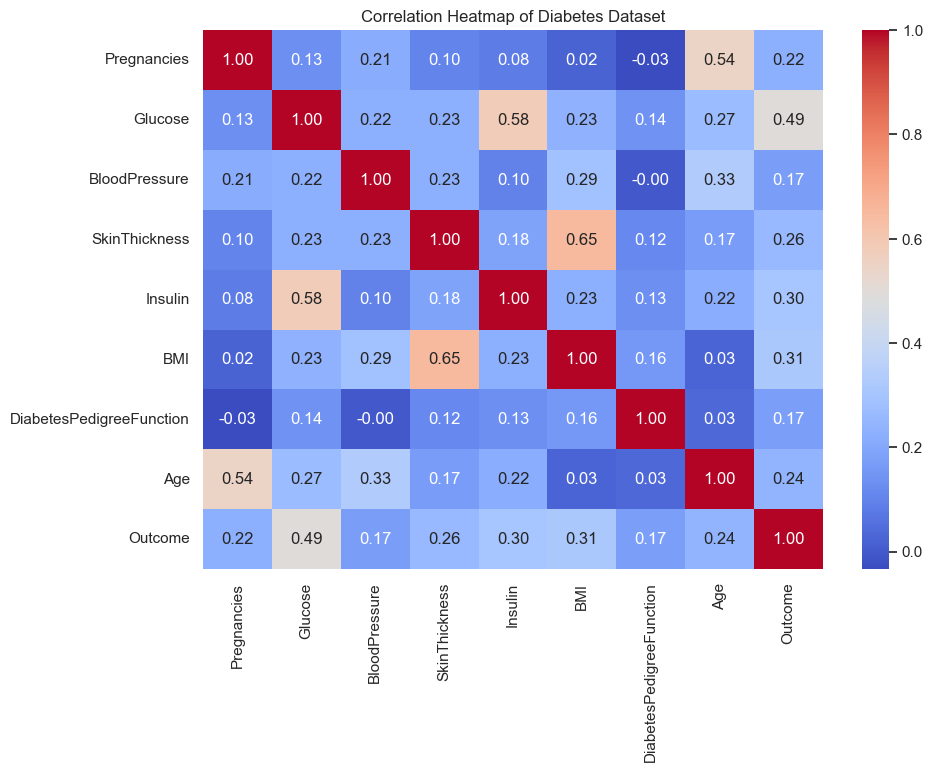

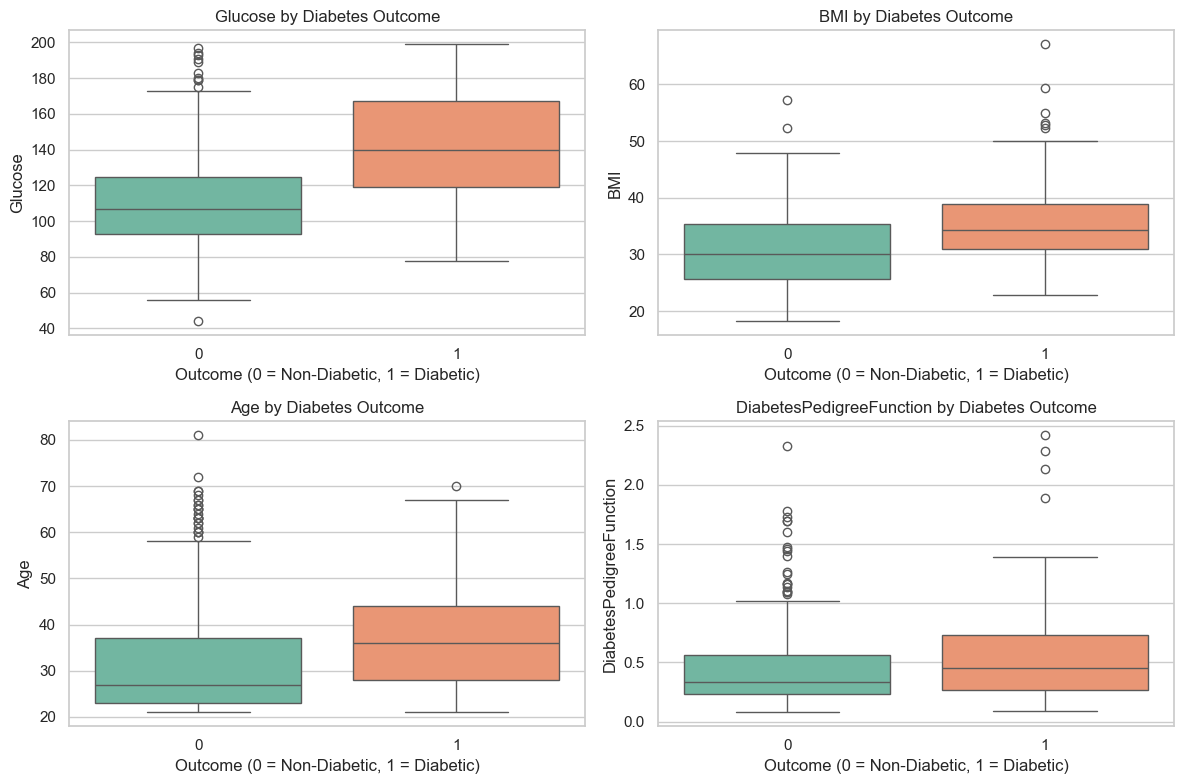

In [19]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

# Compare key clinical features by outcome
key_features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for index, feature in enumerate(key_features):
    sns.boxplot(data=df_clean, x="Outcome", y=feature, ax=axes[index], palette="Set2")
    axes[index].set_title(f"{feature} by Diabetes Outcome")
    axes[index].set_xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")

plt.tight_layout()
plt.show()

## Train-Test Split and Model Setup

The dataset is split using stratification so that the diabetic and non-diabetic class proportions remain similar in both training and testing data. Median imputation and standard scaling are placed inside Scikit-Learn pipelines to avoid data leakage.

In [20]:
# Separate features and target
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

# Common preprocessing: median imputation for missing values and feature scaling
preprocessing_steps = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    model_name: Pipeline(preprocessing_steps + [("model", model)])
    for model_name, model in models.items()
}

Training set shape: (614, 8)
Testing set shape: (154, 8)

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


## Train and Evaluate Three Models

The three selected models are:

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

They are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and cross-validation accuracy.

In [21]:
# Train models and collect performance metrics
results = []
trained_models = {}
predictions = {}
prediction_probabilities = {}
confusion_matrices = {}

for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")

    trained_models[model_name] = pipeline
    predictions[model_name] = y_pred
    prediction_probabilities[model_name] = y_proba
    confusion_matrices[model_name] = np.array([[tn, fp], [fn, tp]])

    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "CV Accuracy Mean": cv_scores.mean(),
            "CV Accuracy Std": cv_scores.std(),
            "True Positives": tp,
            "False Positives": fp,
            "True Negatives": tn,
            "False Negatives": fn,
        }
    )

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy Mean,CV Accuracy Std,True Positives,False Positives,True Negatives,False Negatives
0,Random Forest,0.733766,0.644444,0.537037,0.585859,0.815833,0.760576,0.027581,29,16,84,25
1,Logistic Regression,0.733766,0.603175,0.703704,0.649573,0.812593,0.752486,0.034442,38,25,75,16
2,K-Nearest Neighbors,0.727273,0.625000,0.555556,0.588235,0.790000,0.757404,0.032224,30,18,82,24


In [22]:
# Detailed classification report for each model
for model_name in pipelines:
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_test, predictions[model_name], target_names=["Non-Diabetic", "Diabetic"]))

Logistic Regression
              precision    recall  f1-score   support

Non-Diabetic       0.82      0.75      0.79       100
    Diabetic       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

K-Nearest Neighbors
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.82      0.80       100
    Diabetic       0.62      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154

Random Forest
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.84      0.80       100
    Diabetic       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0

## Confusion Matrices

A confusion matrix shows how many patients were correctly or incorrectly classified. For this medical task, the most important error type is often the false negative, where a diabetic patient is incorrectly predicted as non-diabetic.

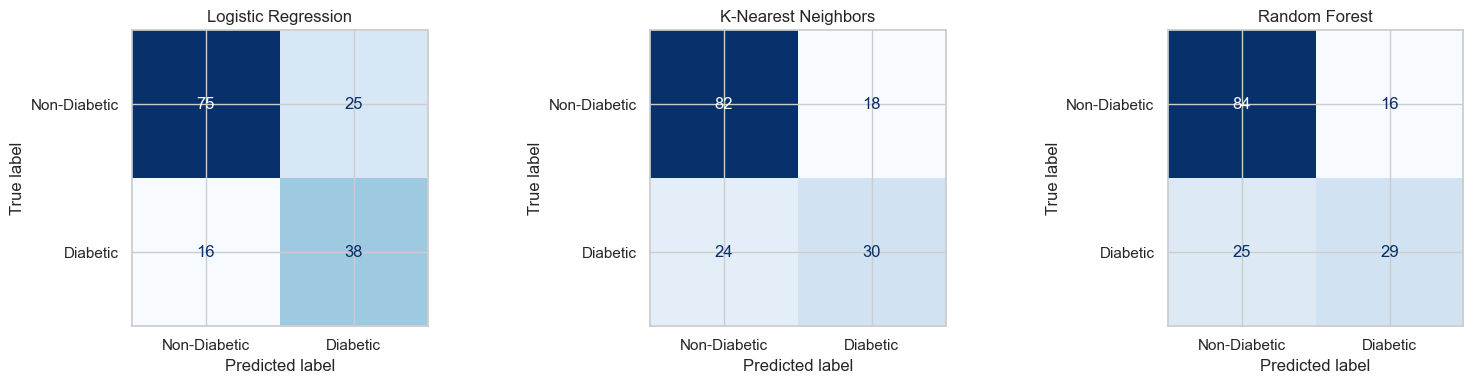

In [23]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Diabetic", "Diabetic"],
    )
    cm_display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## ROC Curves

ROC curves compare how well each model separates diabetic and non-diabetic patients across different classification thresholds. A larger ROC-AUC score indicates stronger overall discrimination.

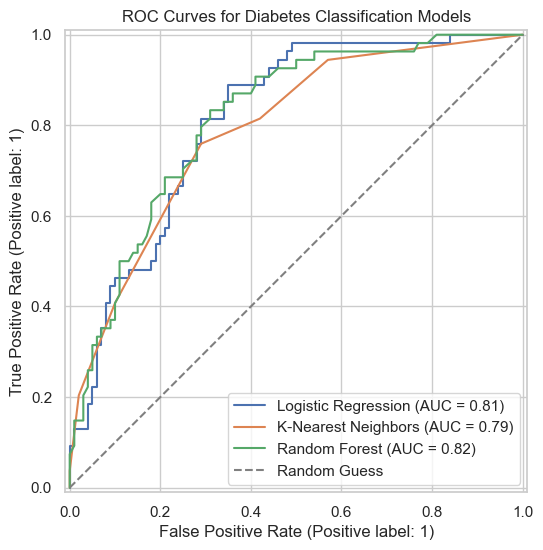

In [24]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))
ax = plt.gca()

for model_name, pipeline in trained_models.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=model_name, ax=ax)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curves for Diabetes Classification Models")
plt.legend()
plt.show()

## Clinical Trade-Off Analysis

In diabetes screening, the two main classification errors have different clinical consequences:

- **False Positive:** A non-diabetic patient is predicted as diabetic. This may cause stress and extra medical testing, but follow-up testing can usually correct the result.
- **False Negative:** A diabetic patient is predicted as non-diabetic. This is more dangerous because the patient may miss treatment, lifestyle intervention, and medical monitoring.

Because missing a diabetic patient can lead to serious health complications, recall is especially important. A good diagnostic model should have high recall while still maintaining acceptable precision and ROC-AUC.

In [25]:
# Select the best diagnostic predictor using clinically relevant priorities
# Priority: high recall first, then ROC-AUC and F1-score.
diagnostic_ranking = results_df.sort_values(
    by=["Recall", "ROC-AUC", "F1-Score"],
    ascending=False,
).reset_index(drop=True)

best_model_name = diagnostic_ranking.loc[0, "Model"]
best_row = diagnostic_ranking.loc[0]
ranking_columns = ["Model", "Recall", "Precision", "F1-Score", "ROC-AUC", "False Negatives", "False Positives"]

print("Clinical diagnostic ranking:")
print(diagnostic_ranking[ranking_columns].to_string(index=False))

print(f"\nBest diagnostic predictor: {best_model_name}")
print(
    f"{best_model_name} is selected because it gives the strongest clinically useful balance, "
    f"with recall = {best_row['Recall']:.3f}, precision = {best_row['Precision']:.3f}, "
    f"ROC-AUC = {best_row['ROC-AUC']:.3f}, false negatives = {int(best_row['False Negatives'])}, "
    f"and false positives = {int(best_row['False Positives'])}."
)
print(
    "For diabetes diagnosis support, reducing false negatives is more important than reducing false positives, "
    "because an undetected diabetic patient may miss timely treatment and monitoring."
)

Clinical diagnostic ranking:
              Model   Recall  Precision  F1-Score  ROC-AUC  False Negatives  False Positives
Logistic Regression 0.703704   0.603175  0.649573 0.812593               16               25
K-Nearest Neighbors 0.555556   0.625000  0.588235 0.790000               24               18
      Random Forest 0.537037   0.644444  0.585859 0.815833               25               16

Best diagnostic predictor: Logistic Regression
Logistic Regression is selected because it gives the strongest clinically useful balance, with recall = 0.704, precision = 0.603, ROC-AUC = 0.813, false negatives = 16, and false positives = 25.
For diabetes diagnosis support, reducing false negatives is more important than reducing false positives, because an undetected diabetic patient may miss timely treatment and monitoring.
